In [1]:
import numpy as np

In [2]:
METHODS  = {"LoCoMotif": "locomotif", "VALMOD": "valmod", "SetFinder": "setfinder", "LatentMotifs": "latentmotifs", "Motiflets": "motiflets"}
VAR_LENGTH_DATASETS = ["CharacterTrajectories", "SpokenArabicDigits", "JapaneseVowels"]
FIX_LENGTH_DATASETS = ["ArticularyWordRecognition", "ERing", "Plane", "Cricket", "Mallat", "UWaveGestureLibrary", "Symbols", "PenDigits", "Fungi", "NATOPS", "ECG5000"]

In [3]:
import os
import pandas as pd

In [4]:
def load_test_results(ds_name, method, epsilon=None):
    variable_length = epsilon is None
    
    df_dataset = pd.read_pickle(os.path.join("ucr_datasets", ds_name.lower(), 'train.pkl'))
    lengths  = df_dataset['length'].to_numpy()    
    if variable_length:
        l_min = int(np.quantile(lengths, 0.1, method='closest_observation'))
        l_max = int(np.quantile(lengths, 0.9, method='closest_observation'))
    else:
        l = min(lengths)
        l_min = int(l - epsilon * l)
        l_max = int(l + epsilon * l)
                
    # Then load results
    path_to_ts = os.path.join("benchmarks", ds_name.lower(), "test.pkl")
    df_ts = pd.read_pickle(path_to_ts)
            
    path_to_result = os.path.join("results", ds_name.lower(), "test")

    file_result = None
    for filename in os.listdir(path_to_result):
        if (method.lower() in filename) and (f"l={l_min}" in filename or f"l_min={l_min}" in filename and f"l_max={l_max:d}" in filename):
            file_result = filename
            
    print(file_result)
    if file_result is None:
        raise ValueError(f"No result for {method} and {ds_name}" + f"with epsilon equal to {epsilon}." if not variable_length else ".")
        
    df_results  = pd.read_pickle(os.path.join(path_to_result, file_result))
    df_results = df_results.reset_index(drop=True)

    df = pd.concat((df_ts, df_results), axis=1)
    return df


In [5]:
results = load_test_results("CharacterTrajectories", "locomotif")

test_locomotif_l_min=83_l_max=142_rho=0.9_warping=True_nb=14.pkl


In [6]:
import locomotif.visualize as vis
import matplotlib.pyplot as plt

+----+---+---+---+---+---+---+---+---+---+----+
|    | 2 | 8 | 5 | 1 | 3 | 4 | 6 | 7 | 9 | MD |
+----+---+---+---+---+---+---+---+---+---+----+
| 12 | 4 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0  |
+----+---+---+---+---+---+---+---+---+---+----+
| 8  | 0 | 2 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 2  |
+----+---+---+---+---+---+---+---+---+---+----+
| 10 | 0 | 0 | 2 | 1 | 0 | 0 | 1 | 0 | 0 | 0  |
+----+---+---+---+---+---+---+---+---+---+----+
| FD | 0 | 0 | 0 | 5 | 2 | 2 | 1 | 2 | 2 | -  |
+----+---+---+---+---+---+---+---+---+---+----+
1.0
0.6666666666666666
0.8


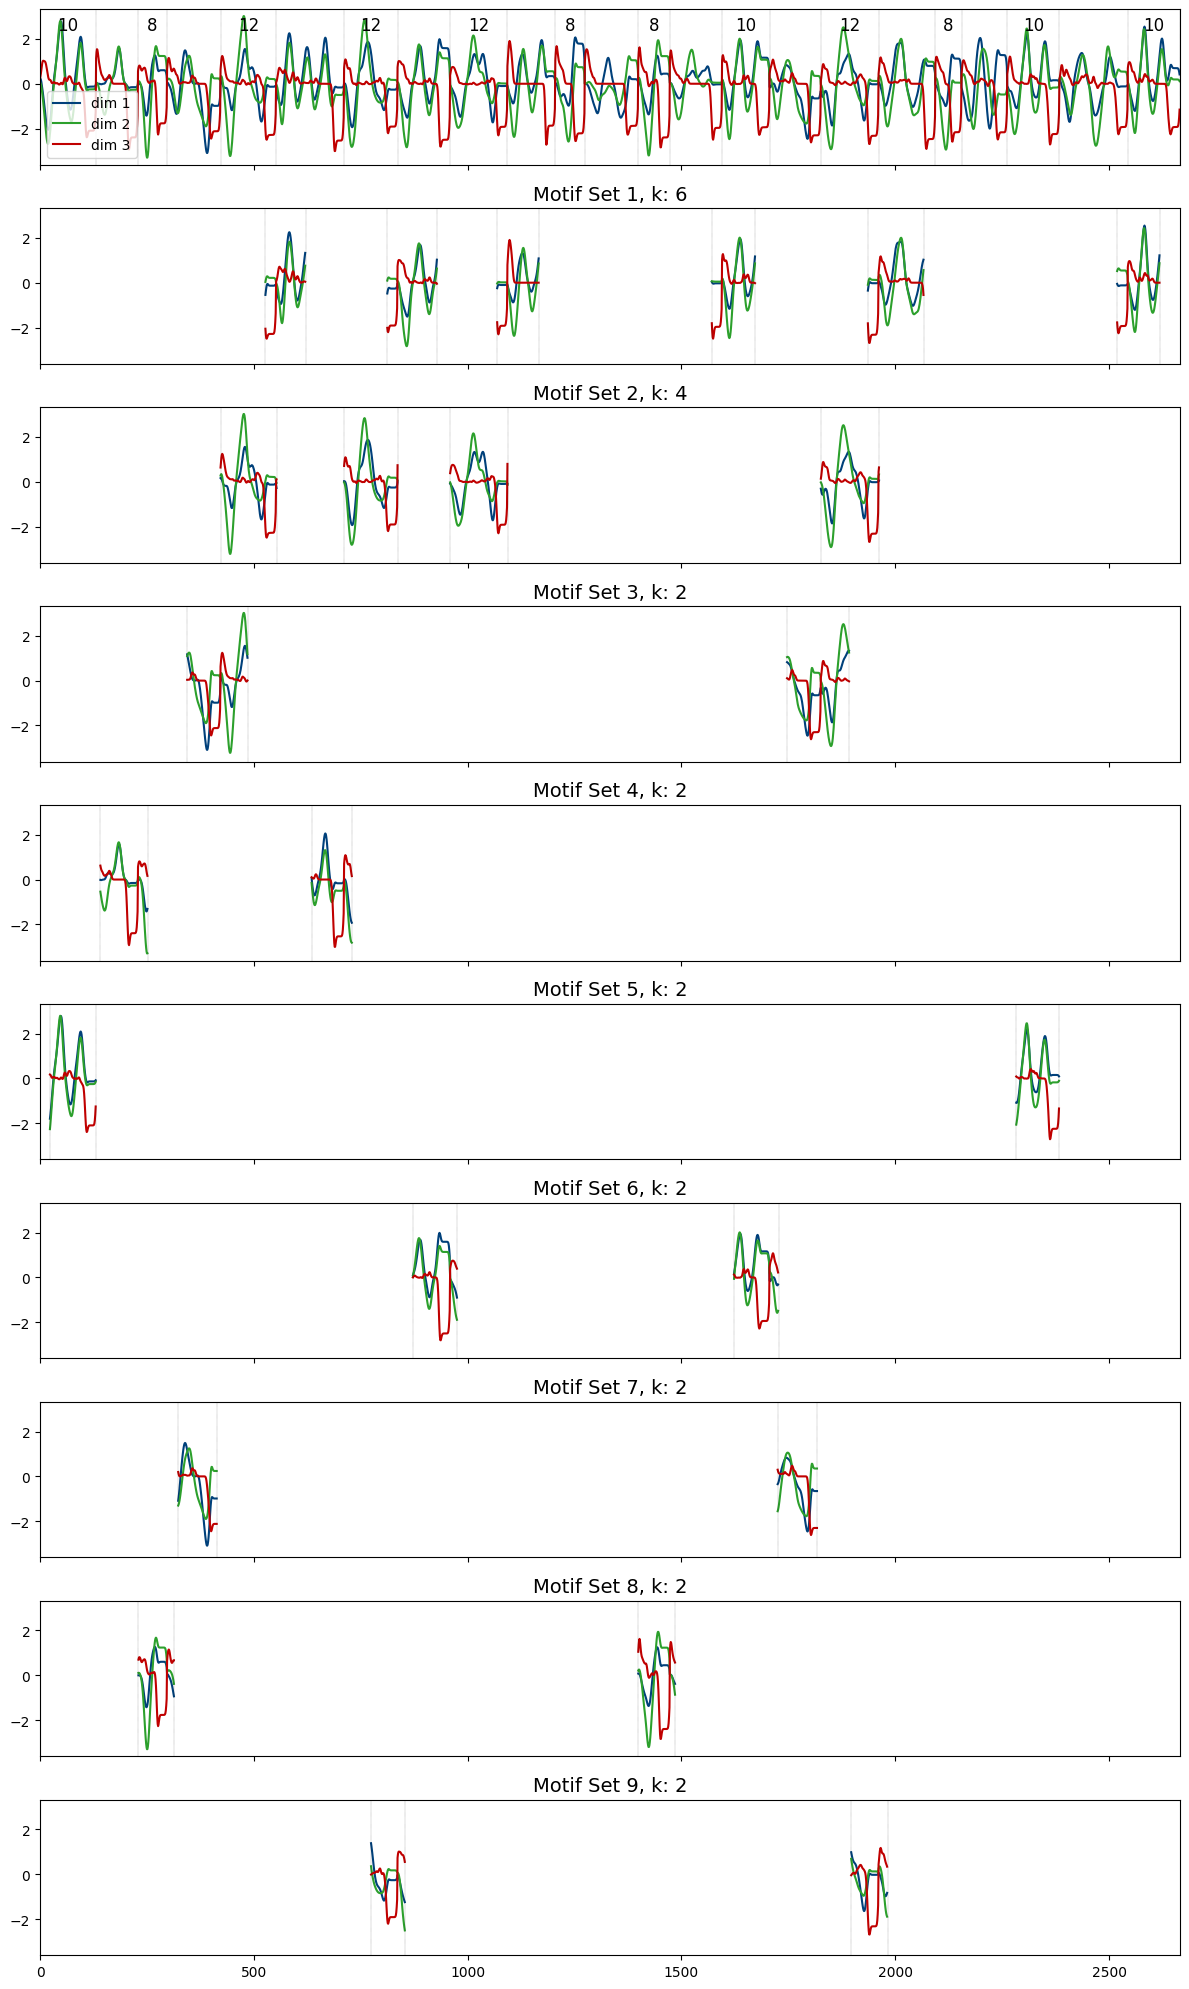

In [11]:
ts, gt, motif_sets, *_ = results.iloc[0]

import evaluation
mm, row_names, col_names = evaluation.match_matrix(gt, motif_sets)
print(evaluation.pretty_print_match_matrix(mm, row_names, col_names))

print(evaluation.precision(mm))
print(evaluation.recall(mm))
print(evaluation.f1_score(mm))

vis.plot_motif_sets(ts, motif_sets, gt)
plt.show()